# Fuel Efficiency Prediction: Linear Regression vs Random Forest

This project predicts vehicle fuel efficiency (MPG) using machine learning regression models. The goal is to compare a simple interpretable model, Linear Regression, with a more flexible ensemble model, Random Forest Regressor.

## 1. Load Dataset

The dataset used in this project is the MPG dataset from Seaborn. It contains technical characteristics of cars, such as horsepower, weight, displacement and model year, along with the target variable `mpg`.

In [48]:
import seaborn as sns
dataset = sns.load_dataset("mpg")
dataset.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


The first five rows of the dataset are displayed to gain an initial understanding of the available features, data types and overall structure of the dataset.

In [49]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


The dataset contains both numerical and categorical features. The `info()` output is used to identify data types, missing values and the overall structure of the dataset.

In [50]:
dataset.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


From the statistical summary, it can be observed that the numerical variables are measured on different scales. This indicates that feature scaling will be required before training the Linear Regression model.

In addition, some variables appear to have large ranges and skewed distributions, which motivates further exploration through visualizations.

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to better understand the dataset before model development. This step helps identify missing values, feature distributions, potential outliers and relationships between variables.

In [51]:
dataset.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

The dataset contains missing values only in the `horsepower` feature. These missing observations will be removed before model training.

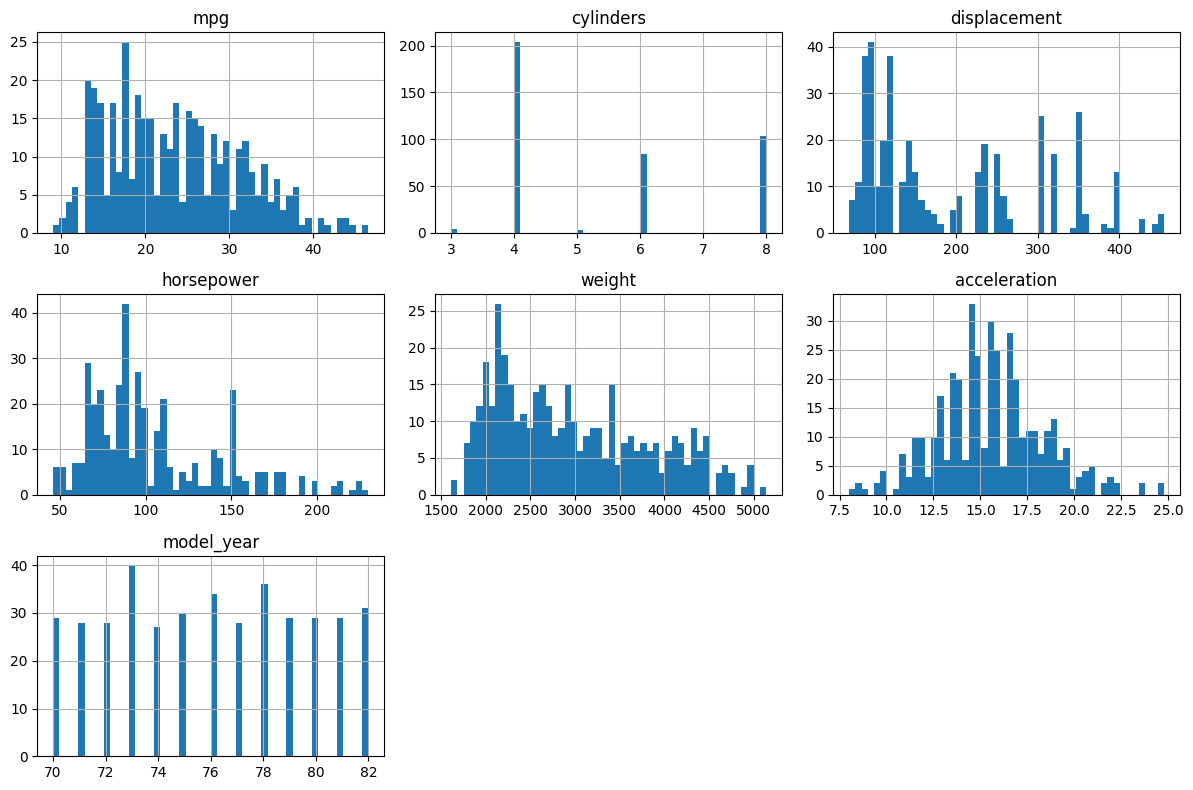

In [52]:
import matplotlib.pyplot as plt
dataset.hist(figsize=(12,8), bins=50)
plt.tight_layout()
plt.show()

The histograms reveal that several numerical variables, such as displacement, horsepower and weight, are right-skewed. This suggests that a logarithmic transformation may improve their distributions before modeling.

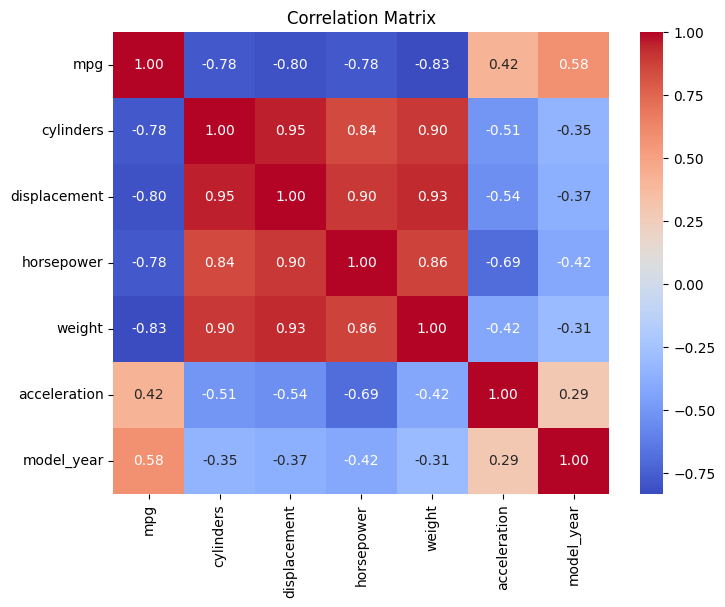

In [53]:
plt.figure(figsize=(8,6))

sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix highlights the relationships between numerical variables. Strong correlations between predictors and the target variable (MPG) provide useful information for model development.

## 3. Data Preprocessing

Before training the machine learning models, the dataset is preprocessed to improve data quality and ensure that all features are in an appropriate format for model training.

In [54]:
# Remove missing values
dataset = dataset.dropna()

The `horsepower` feature contains missing values. Since the number of missing observations is small, rows with missing values are removed from the dataset.

In [55]:
# Remove the columns name and origin
dataset = dataset.drop(["name", "origin"], axis=1)

The `name` and `origin` columns are removed. The `name` column is not useful for this regression task, while `origin` is excluded to keep the model focused on the main technical vehicle characteristics

In [56]:
# Create a copy of the original dataset
datasetcopy = dataset.copy()

A copy of the original dataset is created before applying feature transformations. This preserves the original data, allowing comparisons between the transformed and non-transformed features if needed.

In [57]:
# Apply logarithmic transformation
from sklearn.preprocessing import FunctionTransformer
import numpy as np

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

datasetcopy["displacement"] = log_transformer.transform(datasetcopy[["displacement"]])
datasetcopy["horsepower"] = log_transformer.transform(datasetcopy[["horsepower"]])
datasetcopy["weight"] = log_transformer.transform(datasetcopy[["weight"]])

A logarithmic transformation is applied to highly right-skewed numerical features. This transformation reduces skewness and can improve the performance of regression models by making the feature distributions more symmetric.

In [58]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_encoder = OneHotEncoder(sparse_output=False)

encoded = cat_encoder.fit_transform(datasetcopy[["cylinders"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=cat_encoder.get_feature_names_out(["cylinders"]),
    index=datasetcopy.index
)

datasetcopy = datasetcopy.drop("cylinders", axis=1)
datasetcopy = pd.concat([datasetcopy, encoded_df], axis=1)

The `cylinders` feature is a discrete numerical variable. One-hot encoding is applied so that the model treats each cylinder category separately instead of assuming a strictly linear numerical relationship.

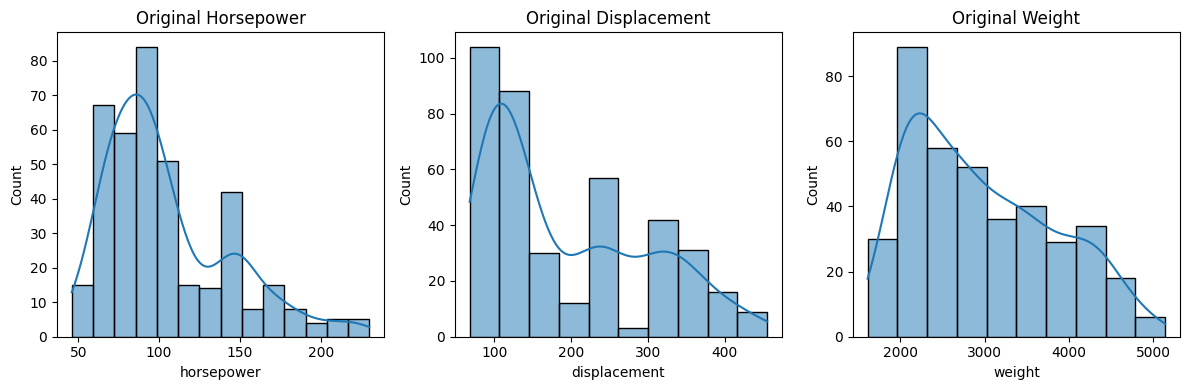

In [59]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(dataset["horsepower"], kde=True)
plt.title("Original Horsepower")

plt.subplot(1,3,2)
sns.histplot(dataset["displacement"], kde=True)
plt.title("Original Displacement")

plt.subplot(1,3,3)
sns.histplot(dataset["weight"], kde=True)
plt.title("Original Weight")

plt.tight_layout()
plt.show()

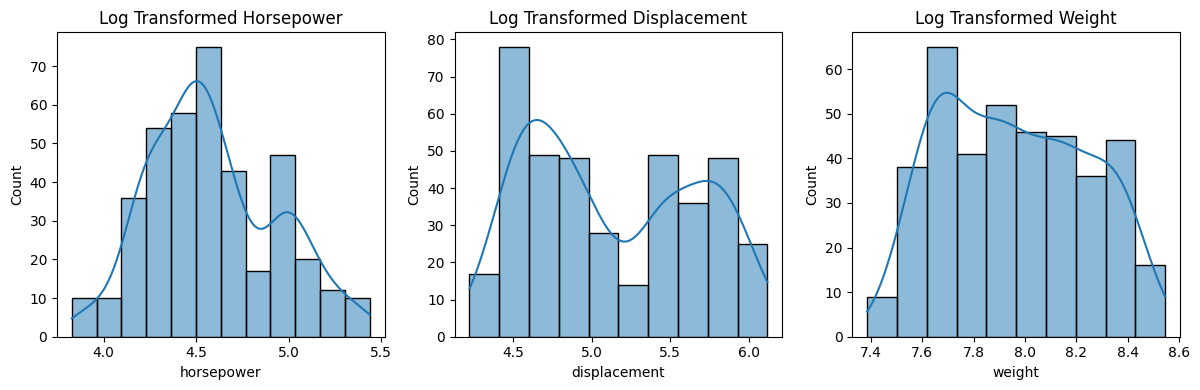

In [60]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(datasetcopy["horsepower"], kde=True)
plt.title("Log Transformed Horsepower")

plt.subplot(1,3,2)
sns.histplot(datasetcopy["displacement"], kde=True)
plt.title("Log Transformed Displacement")

plt.subplot(1,3,3)
sns.histplot(datasetcopy["weight"], kde=True)
plt.title("Log Transformed Weight")

plt.tight_layout()
plt.show()

The logarithmic transformation reduces the right skewness of the numerical variables, resulting in more symmetric distributions. This can improve the performance of linear regression models by making the relationship between predictors and the target variable closer to linear.

## 4. Train-Test Split

The preprocessed dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is reserved for evaluating their performance on unseen data.

In [61]:
from sklearn.model_selection import train_test_split

X = datasetcopy.drop("mpg", axis=1)
y = datasetcopy["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Splitting the dataset before training helps evaluate the model on unseen data. This provides a more realistic estimate of how well the model will perform on new observations and helps reduce the risk of overfitting.

## 5. Linear Regression Model

Linear Regression is used as the baseline regression model for predicting vehicle fuel efficiency (MPG). A machine learning pipeline is created to standardize the numerical features before fitting the model. Standardization ensures that all features are on a similar scale and improves the stability of the regression model.

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("standardize", StandardScaler()),
    ("model", LinearRegression())
])

In [63]:
# Model training
pipeline.fit(X_train, y_train)

,steps,"[('standardize', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


The pipeline is trained using the training dataset. During this step, the numerical features are standardized and the Linear Regression model learns the relationship between the predictor variables and the target variable (MPG).

In [64]:
# Model prediction
final_predictions = pipeline.predict(X_test)

After training, the fitted model is used to predict fuel efficiency values for the unseen test dataset.

### Model Evaluation

In [65]:
# Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error

final_r2 = r2_score(y_test, final_predictions)
final_mae = mean_absolute_error(y_test, final_predictions)

print(final_r2)
print(final_mae)

0.8386948219175643
2.2492945055415423


The model is evaluated using two regression metrics:

- **R² Score** measures how much of the variance in MPG is explained by the model.
- **Mean Absolute Error (MAE)** measures the average prediction error between the predicted and actual MPG values.

The Linear Regression model achieved an **R² score of approximately 0.84**, meaning that it explains around **84% of the variability** in fuel efficiency.

The **Mean Absolute Error (MAE) is approximately 2.25 MPG**, indicating that, on average, the model's predictions differ from the actual fuel efficiency values by about 2.25 MPG.

### Actual vs Predicted Values

A scatter plot is used to compare the actual MPG values with the values predicted by the Linear Regression model. If the model performs well, most observations should lie close to the diagonal reference line.

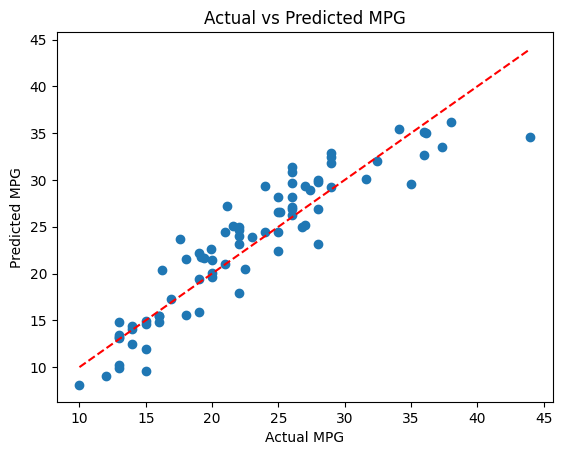

In [66]:
# Create scatterplot
plt.scatter(y_test, final_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.show()

Most observations are located close to the diagonal reference line, indicating that the model predicts fuel efficiency with good accuracy.

Some deviations from the line are expected because Linear Regression assumes a linear relationship and cannot capture all complex patterns in the data.

### Cross Validation

To obtain a more reliable estimate of the model's performance, a **10-fold cross-validation** is performed on the training dataset.

Unlike a single train-test split, cross-validation evaluates the model on multiple subsets of the data, providing a more robust estimate of its ability to generalize to unseen observations.

In [67]:
from sklearn.model_selection import cross_val_score

crossr2 = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring="r2",
    cv=10
)

pd.Series(crossr2).describe()

count    10.000000
mean      0.846758
std       0.043642
min       0.767530
25%       0.811209
50%       0.868662
75%       0.877101
max       0.894333
dtype: float64

The mean R² score across the ten folds represents the average predictive performance of the model, while the standard deviation indicates how consistently the model performs across different subsets of the data.

In [68]:
crossmae = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=10
)

pd.Series(-crossmae).describe()

count    10.000000
mean      2.242051
std       0.418883
min       1.716906
25%       1.980940
50%       2.187892
75%       2.338885
max       3.185899
dtype: float64

The average Mean Absolute Error obtained from cross-validation is consistent with the test set evaluation, indicating that the model maintains stable predictive performance across different training subsets.

### Linear Regression Summary

The Linear Regression model demonstrated strong predictive performance, achieving an **R² score of approximately 0.84** and a **Mean Absolute Error of around 2.25 MPG**.

Furthermore, the 10-fold cross-validation results confirmed that the model performs consistently across different subsets of the training data, indicating good generalization ability.

Although the model provides accurate predictions, Linear Regression assumes a linear relationship between the predictor variables and fuel efficiency. In the next section, a more flexible machine learning algorithm, **Random Forest Regressor**, will be trained and evaluated to determine whether it can better capture the underlying relationships in the dataset.

## 6. Random Forest Regression

Random Forest Regressor is used as a second regression model to compare against Linear Regression. Unlike Linear Regression, Random Forest can capture non-linear relationships between the predictor variables and fuel efficiency.
This makes it useful for evaluating whether a more flexible model can improve predictive performance.

In [69]:
# Create the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [70]:
# Model training
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
# Model prediction
rf_predictions = rf_model.predict(X_test)

After training, the Random Forest model is used to predict MPG values for the test dataset.

### Model Evaluation

The Random Forest model is evaluated using the same metrics as Linear Regression: R² score and Mean Absolute Error. This allows a fair comparison between the two models.

In [72]:
rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(rf_r2)
print(rf_mae)

0.891673743163745
1.7110886075949343


The Random Forest Regressor achieved an R² score of approximately **0.89** and a Mean Absolute Error of approximately **1.71** MPG.

### Actual vs Predicted Values

A scatter plot is used to compare the actual MPG values with the values predicted by the Random Forest model. If the model performs well, most observations should lie close to the diagonal reference line.

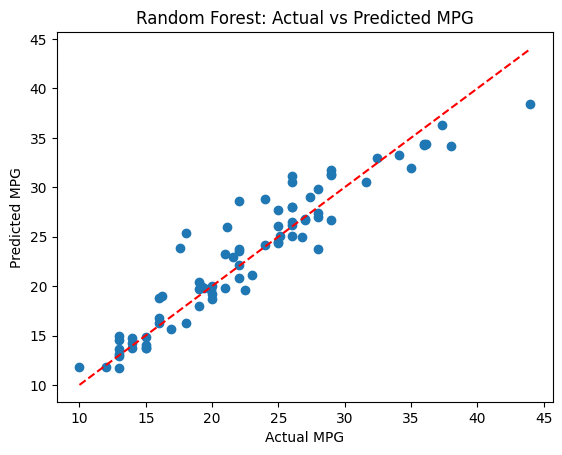

In [73]:
plt.scatter(y_test, rf_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Random Forest: Actual vs Predicted MPG")

plt.show()

Most observations are located close to the diagonal reference line, indicating that the Random Forest model predicts fuel efficiency with high accuracy.

Compared with the Linear Regression model, the predictions appear slightly closer to the reference line, suggesting that Random Forest captures more complex relationships between the predictor variables and fuel efficiency.

### Cross Validation

To obtain a more reliable estimate of the model's performance, a **10-fold cross-validation** is performed.

Cross-validation evaluates the model on multiple subsets of the training data, providing a more robust estimate of its ability to generalize to unseen observations.

In [74]:
rf_crossr2 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring="r2",
    cv=10
)

pd.Series(rf_crossr2).describe()

count    10.000000
mean      0.861398
std       0.073852
min       0.684070
25%       0.850738
50%       0.880535
75%       0.899605
max       0.954671
dtype: float64

The mean R² score across the ten folds provides a reliable estimate of the model's predictive performance, while the standard deviation indicates how consistently the model performs across different training subsets.

In [75]:
rf_crossmae = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=10
)

pd.Series(-rf_crossmae).describe()

count    10.000000
mean      2.029746
std       0.440849
min       1.386594
25%       1.660879
50%       2.010464
75%       2.411488
max       2.621161
dtype: float64

The average Mean Absolute Error obtained through cross-validation provides an estimate of the model's prediction error across multiple training subsets.

A relatively small standard deviation indicates that the Random Forest model produces stable and consistent predictions.

### Random Forest Summary

The Random Forest Regressor achieved better predictive performance than the Linear Regression model.

It obtained a higher **R² score (approximately 0.89)** and a lower **Mean Absolute Error (approximately 1.71 MPG)**, indicating more accurate predictions.

The cross-validation results also demonstrated consistent performance across different training subsets, suggesting that the model generalizes well to unseen data.

These findings indicate that Random Forest is better suited for capturing the complex relationships between vehicle characteristics and fuel efficiency in this dataset.

## 7. Model Comparison

The performance of the Linear Regression and Random Forest models is compared using the same evaluation metrics.

The comparison includes:

- Test R² Score
- Test Mean Absolute Error (MAE)
- Mean Cross-Validation R²
- Mean Cross-Validation MAE

This allows a fair assessment of the strengths and weaknesses of each model.

In [76]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test R²": [
        final_r2,
        rf_r2
    ],
    "Test MAE": [
        final_mae,
        rf_mae
    ],
    "CV Mean R²": [
        crossr2.mean(),
        rf_crossr2.mean()
    ],
    "CV Mean MAE": [
        (-crossmae).mean(),
        (-rf_crossmae).mean()
    ]
})

comparison

,Model,Test R²,Test MAE,CV Mean R²,CV Mean MAE
0,Linear Regression,0.838695,2.249295,0.846758,2.242051
1,Random Forest,0.891674,1.711089,0.861398,2.029746


## Visual Comparison

The following charts summarize the performance of both regression models and provide an easy visual comparison.

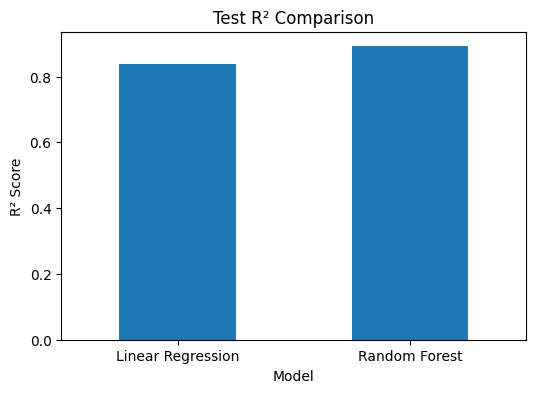

In [77]:
comparison.plot(
    x="Model",
    y="Test R²",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("R² Score")
plt.title("Test R² Comparison")

plt.xticks(rotation=0)

plt.show()

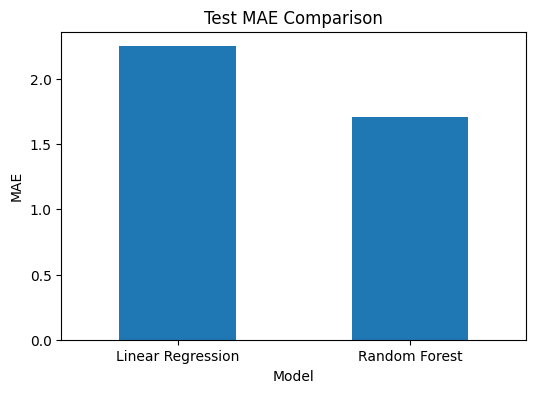

In [78]:
comparison.plot(
    x="Model",
    y="Test MAE",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("MAE")
plt.title("Test MAE Comparison")

plt.xticks(rotation=0)

plt.show()

The comparison shows that the Random Forest Regressor achieved a higher R² score and a lower Mean Absolute Error than the Linear Regression model.

These results indicate that Random Forest provides more accurate predictions and captures the complex relationships within the dataset more effectively.

## 8. Final Conclusion

This project explored two machine learning regression models for predicting vehicle fuel efficiency (MPG): Linear Regression and Random Forest Regressor.

The complete workflow included:

- Data exploration
- Data preprocessing
- Feature engineering
- Model training
- Performance evaluation
- Cross-validation
- Model comparison

Although Linear Regression provided strong baseline performance, the Random Forest Regressor consistently achieved higher predictive accuracy and lower prediction error.

Overall, Random Forest proved to be the most suitable model for this dataset because it can capture non-linear relationships between vehicle characteristics and fuel efficiency.

This project demonstrates the importance of comparing multiple machine learning models before selecting the most appropriate solution for a regression problem.